# Multimodal Semantic Search with Gemini Embedding 2 + Qdrant

> **Author:** Mohamed Arbi Nsibi — [LinkedIn](https://www.linkedin.com/in/mohammed-arbi-nsibi-584a43241/)

---

`gemini-embedding-2-preview` is Google's first fully multimodal embedding model, it maps text, images, audio, and PDFs into a **single unified vector space**, enabling cross-modal search without OCR pipelines or intermediate transcription steps.

This notebook demonstrates that capability end-to-end using **Qdrant** as the vector store.

## What we cover

| Section | What it demonstrates |
|---|---|
| **1. Image retrieval** | Index research paper figures (image + caption), query by concept |
| **2. Retrieval evaluation** | Ground-truth query set, precision scoring per figure |
| **3. Proof: image embedding** | experiment proving the model reads image bytes, not just captions |
| **4. PDF RAG** | Index PDF pages as images, retrieve relevant pages by text query |
| **5. Audio RAG** | Chunk audio, embed each segment, retrieve by semantic query |

## Key concepts

- **Unified vector space** text queries can retrieve images, audio segments, and PDF pages from the same index
- **MRL (Matryoshka Representation Learning)** vectors can be truncated to 768 dims with <0.25% quality loss, giving 4× RAM savings
- **task_type** :`RETRIEVAL_DOCUMENT` vs `RETRIEVAL_QUERY` optimize the embedding manifold for indexing vs searching

---

In [1]:
!pip install qdrant_client -q

In [14]:
import numpy as np
from google import genai
from google.genai import types
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance

GEMINI_API_KEY="YOUR-API-KEY"
client = genai.Client(api_key=GEMINI_API_KEY)
MODEL_ID = "gemini-embedding-2-preview"
COLLECTION_NAME= "multimodal_vault"

qdrant_client = QdrantClient(path ="/content/my-search-engine")

def normalize_vector(vector):
    norm = np.linalg.norm(vector)
    return (vector / norm).tolist() if norm > 0 else vector

In [34]:
imgs = [
    (1, "/content/img/pipeline.png",
     "Flowchart showing the full training sequence: Base Model → Single-Turn Model → Actor Model + Critic Model → CUDA Agent, connected by PPO and RFT arrows across three dashed-border stages"),

    (2, "/content/img/remove-rft-impact.png",
     "Ablation: removing RFT collapses training reward to 0 and spikes actor entropy after step 20"),

    (3, "/content/img/limitations-single-turn.png",
     "Ablation table: w/o Agent Loop drops pass rate to 77.1% and speed-up to 0.89x; full CUDA Agent achieves 98.8% and 2.60x"),

    (4, "/content/img/agent_loop.png",
     "Agent loop: CUDA Agent reads SKILL.md + workdir, generates CUDA kernels, executes on GPU pool, receives performance feedback"),

    (5, "/content/img/data_collection.png",
     "Data pipeline: crawl seed ops (matmul, relu, conv2d) → LLM combinatorial synthesis → rubric filtering (executable, non-trivial)"),
]

In [35]:
# create Qdrant Collection (full 3072 Dimensions)
qdrant_client.recreate_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=3072, distance=Distance.COSINE)
)

/tmp/ipykernel_163/1795785843.py:2: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qdrant_client.recreate_collection(


True

In [36]:
points = []
import os
from qdrant_client.models import VectorParams, Distance, PointStruct

for fig_id, img_path, caption in imgs:
    parts = [types.Part(text=caption)]

    if img_path and os.path.exists(img_path):
        with open(img_path, "rb") as f:
            img_bytes = f.read()
        parts.append(types.Part.from_bytes(data=img_bytes, mime_type="image/png"))
        modality = "image+text"
    else:
        modality = "text-only"

    result = client.models.embed_content(
        model=MODEL_ID,
        contents=[types.Content(parts=parts)],
        config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT"),
    )

    points.append(PointStruct(
        id=fig_id,
        vector=result.embeddings[0].values,
        payload={"caption": caption, "modality": modality,
                 "image": img_path or "none"},
    ))
    print(f"  ✓ Indexed fig {fig_id}  [{modality}]  {caption[:60]}...")

qdrant_client.upsert(collection_name=COLLECTION_NAME , points=points)
print(f"\n── Corpus ready: {len(points)} figures indexed ──\n")



  ✓ Indexed fig 1  [image+text]  Flowchart showing the full training sequence: Base Model → S...
  ✓ Indexed fig 2  [image+text]  Ablation: removing RFT collapses training reward to 0 and sp...
  ✓ Indexed fig 3  [image+text]  Ablation table: w/o Agent Loop drops pass rate to 77.1% and ...
  ✓ Indexed fig 4  [image+text]  Agent loop: CUDA Agent reads SKILL.md + workdir, generates C...
  ✓ Indexed fig 5  [image+text]  Data pipeline: crawl seed ops (matmul, relu, conv2d) → LLM c...

── Corpus ready: 5 figures indexed ──



In [37]:
fig1_queries = [
    "flowchart of model training from base model to final agent",     # "flowchart", "base model" → only fig 1
    "diagram showing Base Model Single-Turn Model Actor Critic boxes", # box names → only fig 1
    "what connects Base Model to CUDA Agent step by step",            # "step by step" sequence → fig 1
    "sequence of models produced during training",                    # "sequence of models" → fig 1
]

queries = fig1_queries + [
    # fig 2
    "what happens to training reward if RFT is removed?",
    "ablation study showing training instability",
    # fig 3
    "comparison between single-turn and agent-loop performance",
    "quantitative evidence motivating the agent architecture",
    # fig 4
    "what is the skill-integrated agent loop?",
    "execution feedback loop for code generation",
    # fig 5
    "pipeline for generating RL training examples",
    "trajectory sampling and filtering process",
]

In [38]:
for q in queries:
    q_result = client.models.embed_content(
        model=MODEL_ID,
        contents=[types.Content(parts=[types.Part(text=q)])],
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY"),
    )
    hits = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        query=q_result.embeddings[0].values,
        limit=3,
    ).points

    top = hits[0]
    expected_fig = (
        1 if q in fig1_queries else
        2 if "RFT" in q or "instability" in q else
        3 if "single-turn" in q or "quantitative" in q else
        4 if "agent loop" in q or "feedback" in q else 5
    )
    correct = "✓" if top.id == expected_fig else f"✗ (expected fig {expected_fig})"

    print(f"\n{correct} Q: \"{q}\"")
    for h in hits:
        marker = " ←" if h.id == expected_fig else ""
        print(f"  [{h.score:.4f}] fig {h.id}{marker}")
print("─" * 65)


─────────────────────────────────────────────────────────────────

✓ Q: "flowchart of model training from base model to final agent"
  [0.6074] fig 1 ←
  [0.5337] fig 4
  [0.5059] fig 2

✓ Q: "diagram showing Base Model Single-Turn Model Actor Critic boxes"
  [0.5305] fig 1 ←
  [0.4067] fig 4
  [0.3797] fig 2

✓ Q: "what connects Base Model to CUDA Agent step by step"
  [0.6446] fig 1 ←
  [0.6155] fig 4
  [0.5670] fig 3

✓ Q: "sequence of models produced during training"
  [0.4881] fig 1 ←
  [0.4754] fig 2
  [0.4596] fig 4

✓ Q: "what happens to training reward if RFT is removed?"
  [0.5919] fig 2 ←
  [0.4880] fig 3
  [0.4845] fig 1

✓ Q: "ablation study showing training instability"
  [0.5924] fig 2 ←
  [0.5294] fig 3
  [0.4891] fig 1

✓ Q: "comparison between single-turn and agent-loop performance"
  [0.5744] fig 3 ←
  [0.5657] fig 1
  [0.5496] fig 4

✓ Q: "quantitative evidence motivating the agent architecture"
  [0.5346] fig 3 ←
  [0.5184] fig 1
  [0.5156] fig 4

✓ Q: "what is the

### experiment (Image-only) without captions

In [ ]:
# Gemini 2 rlly embeds the image

from google import genai
from google.genai import types
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PointStruct

def cosine(a, b):
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def embed_parts(parts, task_type="RETRIEVAL_DOCUMENT"):
    return client.models.embed_content(
        model=MODEL_ID,
        contents=[types.Content(parts=parts)],
        config=types.EmbedContentConfig(task_type=task_type),
    ).embeddings[0].values

def load(path):
    with open(path, "rb") as f:
        return f.read()

img_paths = {
    1: "/content/img/pipeline.png",
    2: "/content/img/remove-rft-impact.png",
    3: "/content/img/limitations-single-turn.png",
    4: "/content/img/agent_loop.png",
    5: "/content/img/data_collection.png",
}

In [ ]:
# Image-only collection (no captions at all)
# If text retrieval was driving results, this should fail.
# If image embedding works, text queries should still find the right figure.

print("═" * 65)
print("Image-only index (captions stripped)")
print("═" * 65)

qdrant_client.recreate_collection(
    collection_name="image_only",
    vectors_config=VectorParams(size=3072, distance=Distance.COSINE),
)

for fig_id, path in img_paths.items():
    img_bytes = load(path)
    # pure image embedding
    v = embed_parts([
        types.Part.from_bytes(data=img_bytes, mime_type="image/png")
    ])
    qdrant_client.upsert("image_only", points=[
        PointStruct(id=fig_id, vector=v, payload={"fig_id": fig_id})
    ])
    print(f"  ✓ fig {fig_id} indexed (image only, no caption)")

print()

In [41]:

# Now query with text — no image in the query either
text_queries = [
    ("flowchart Base Model to CUDA Agent training stages",  1),
    ("reward collapse when RFT is removed",                 2),
    ("ablation table pass rate 77 percent agent loop",      3),
    ("CUDA agent reads SKILL.md generates kernels",         4),
    ("seed problem crawling combinatorial synthesis",       5),
]

correct_a = 0
for q, expected in text_queries:
    hits = qdrant_client.query_points(
        collection_name="image_only",
        query=embed_parts([types.Part(text=q)],
                          task_type="RETRIEVAL_QUERY"),
        limit=3,
    ).points
    top = hits[0]
    mark = "✓" if top.id == expected else f"✗ (expected {expected})"
    correct_a += top.id == expected
    print(f"{mark} Q: \"{q}\"")
    print(f"   top result → fig {top.id}  score={top.score:.4f}")

print(f"\nAccuracy (image-only index): {correct_a}/{len(text_queries)}")
print("If > 0 correct → image content is being embedded, not just text\n")



═════════════════════════════════════════════════════════════════
EXPERIMENT A — Image-only index (captions stripped)
═════════════════════════════════════════════════════════════════


/tmp/ipykernel_163/3566707014.py:40: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qdrant_client.recreate_collection(


  ✓ fig 1 indexed (image only, no caption)
  ✓ fig 2 indexed (image only, no caption)
  ✓ fig 3 indexed (image only, no caption)
  ✓ fig 4 indexed (image only, no caption)
  ✓ fig 5 indexed (image only, no caption)

✓ Q: "flowchart Base Model to CUDA Agent training stages"
   top result → fig 1  score=0.5462
✓ Q: "reward collapse when RFT is removed"
   top result → fig 2  score=0.5175
✓ Q: "ablation table pass rate 77 percent agent loop"
   top result → fig 3  score=0.5438
✓ Q: "CUDA agent reads SKILL.md generates kernels"
   top result → fig 4  score=0.5469
✓ Q: "seed problem crawling combinatorial synthesis"
   top result → fig 5  score=0.4615

Accuracy (image-only index): 5/5
If > 0 correct → image content is being embedded, not just text



### PDF

In [44]:
!pip install qdrant-client google-genai pdf2image pillow -q
!apt-get install -q poppler-utils

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s (325 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
import base64, io
from pdf2image import convert_from_path
from google import genai
from google.genai import types
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PointStruct

client  = genai.Client(api_key=GEMINI_API_KEY)
qdrant  = QdrantClient(path="/content/vector-db")
MODEL   = "gemini-embedding-2-preview"

# PDF → page images
pages = convert_from_path("/content/cuda_agent-1-5.pdf", dpi=150)
print(f"{len(pages)} pages")

#collection
qdrant.recreate_collection("pdf_pages",
    vectors_config=VectorParams(size=3072, distance=Distance.COSINE))


In [ ]:
# embed each page as an image
for i, page in enumerate(pages):
    buf = io.BytesIO()
    page.save(buf, format="JPEG")
    img_bytes = buf.getvalue()

    v = client.models.embed_content(
        model=MODEL,
        contents=[types.Content(parts=[
            types.Part(text=f"page {i+1}"),
            types.Part.from_bytes(data=img_bytes, mime_type="image/jpeg"),
        ])],
        config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT"),
    ).embeddings[0].values

    qdrant.upsert("pdf_pages", points=[PointStruct(
        id=i+1, vector=v,
        payload={"page": i+1, "image_b64": base64.b64encode(img_bytes).decode()}
    )])
    print(f"  ✓ page {i+1}")

✓ 5 pages


/tmp/ipykernel_163/1076266933.py:17: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qdrant.recreate_collection("pdf_pages",


  ✓ page 1
  ✓ page 2
  ✓ page 3
  ✓ page 4
  ✓ page 5
page 5  score=0.4493


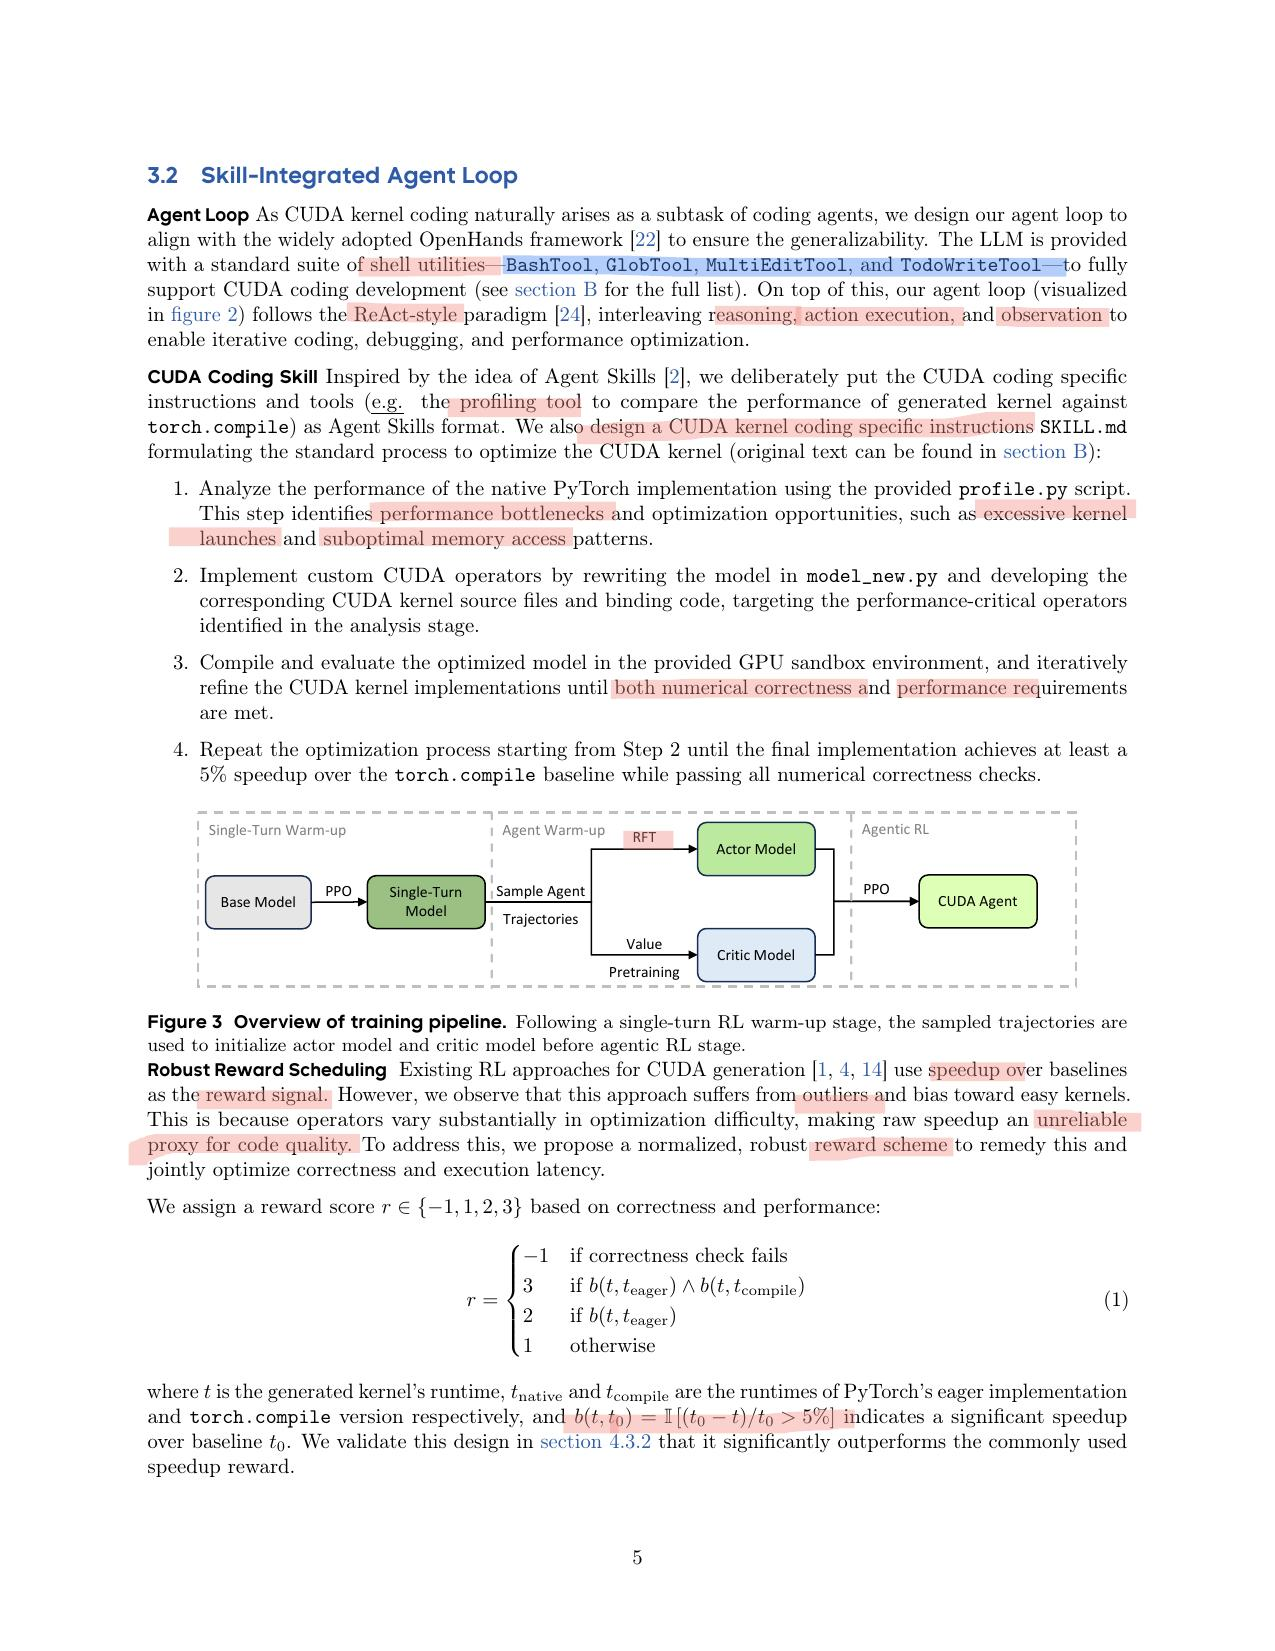

page 1  score=0.4304


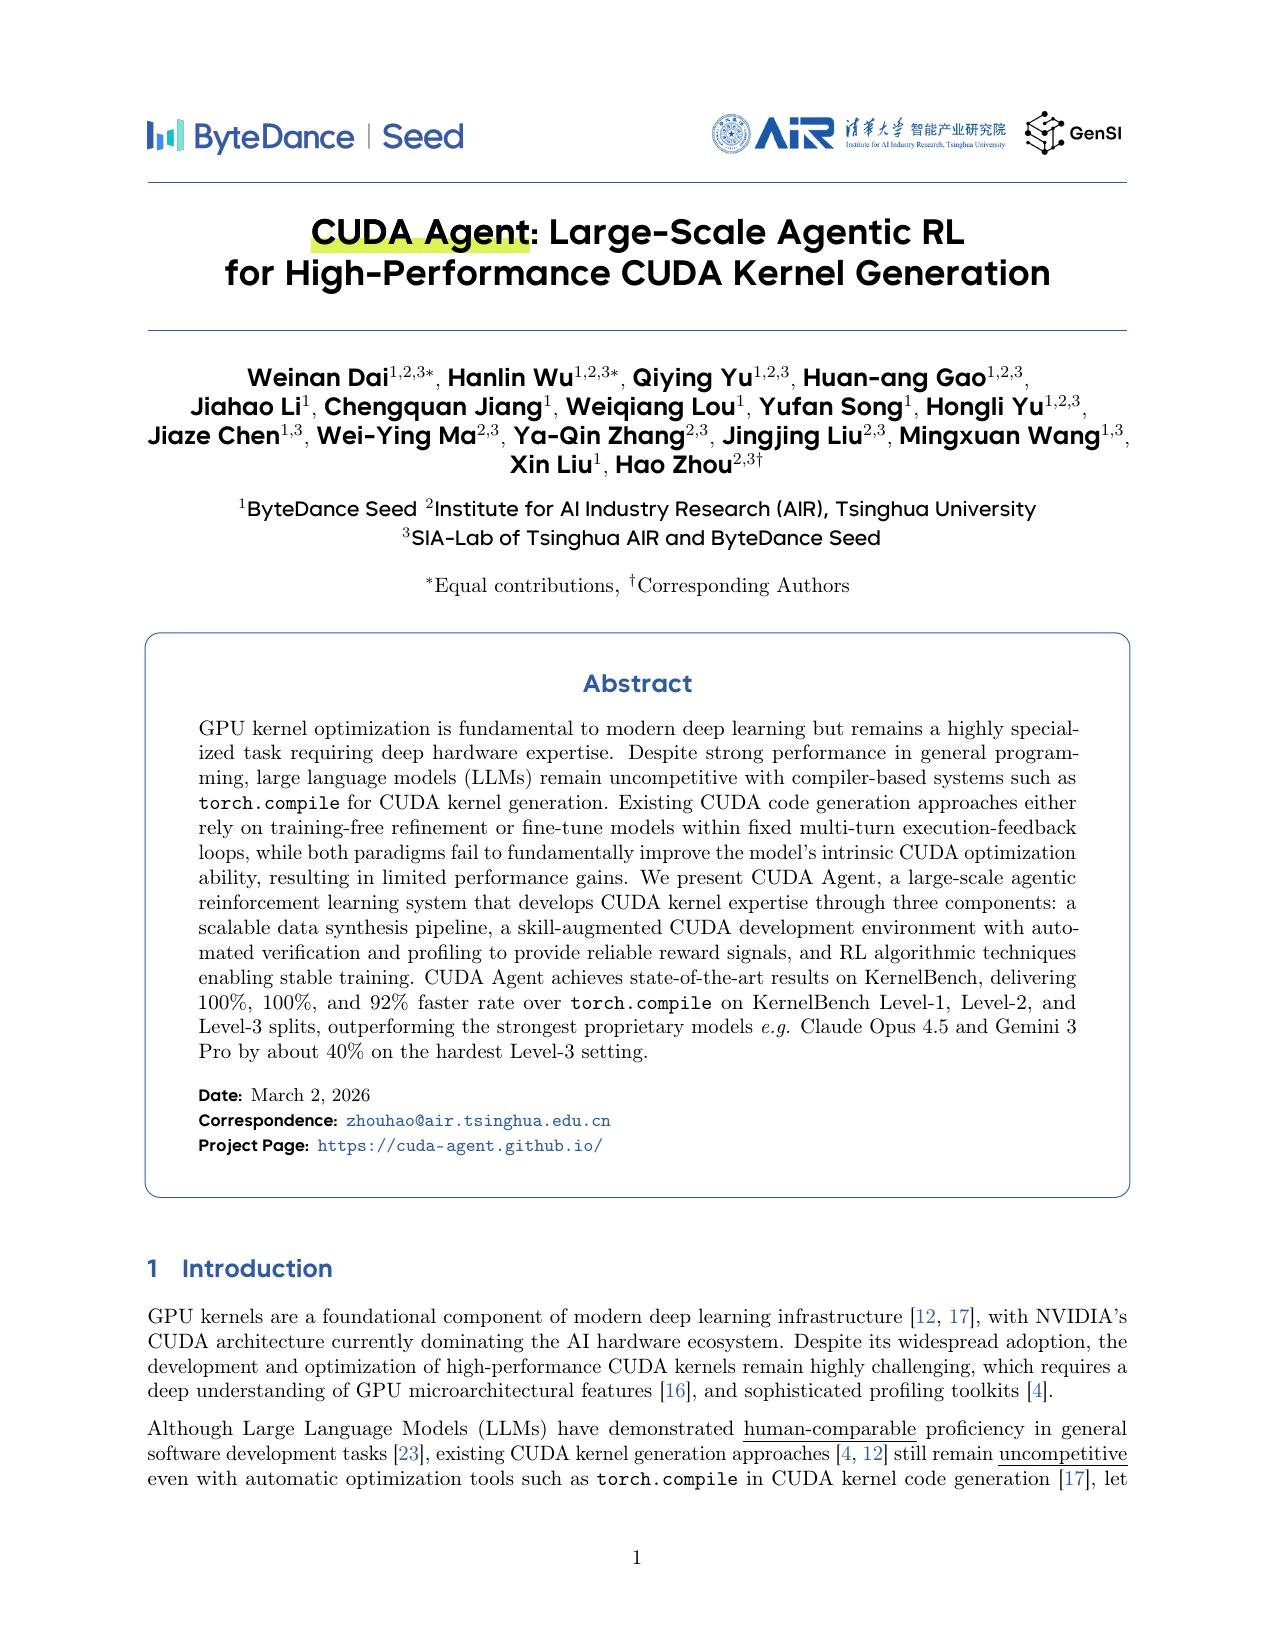

page 4  score=0.4100


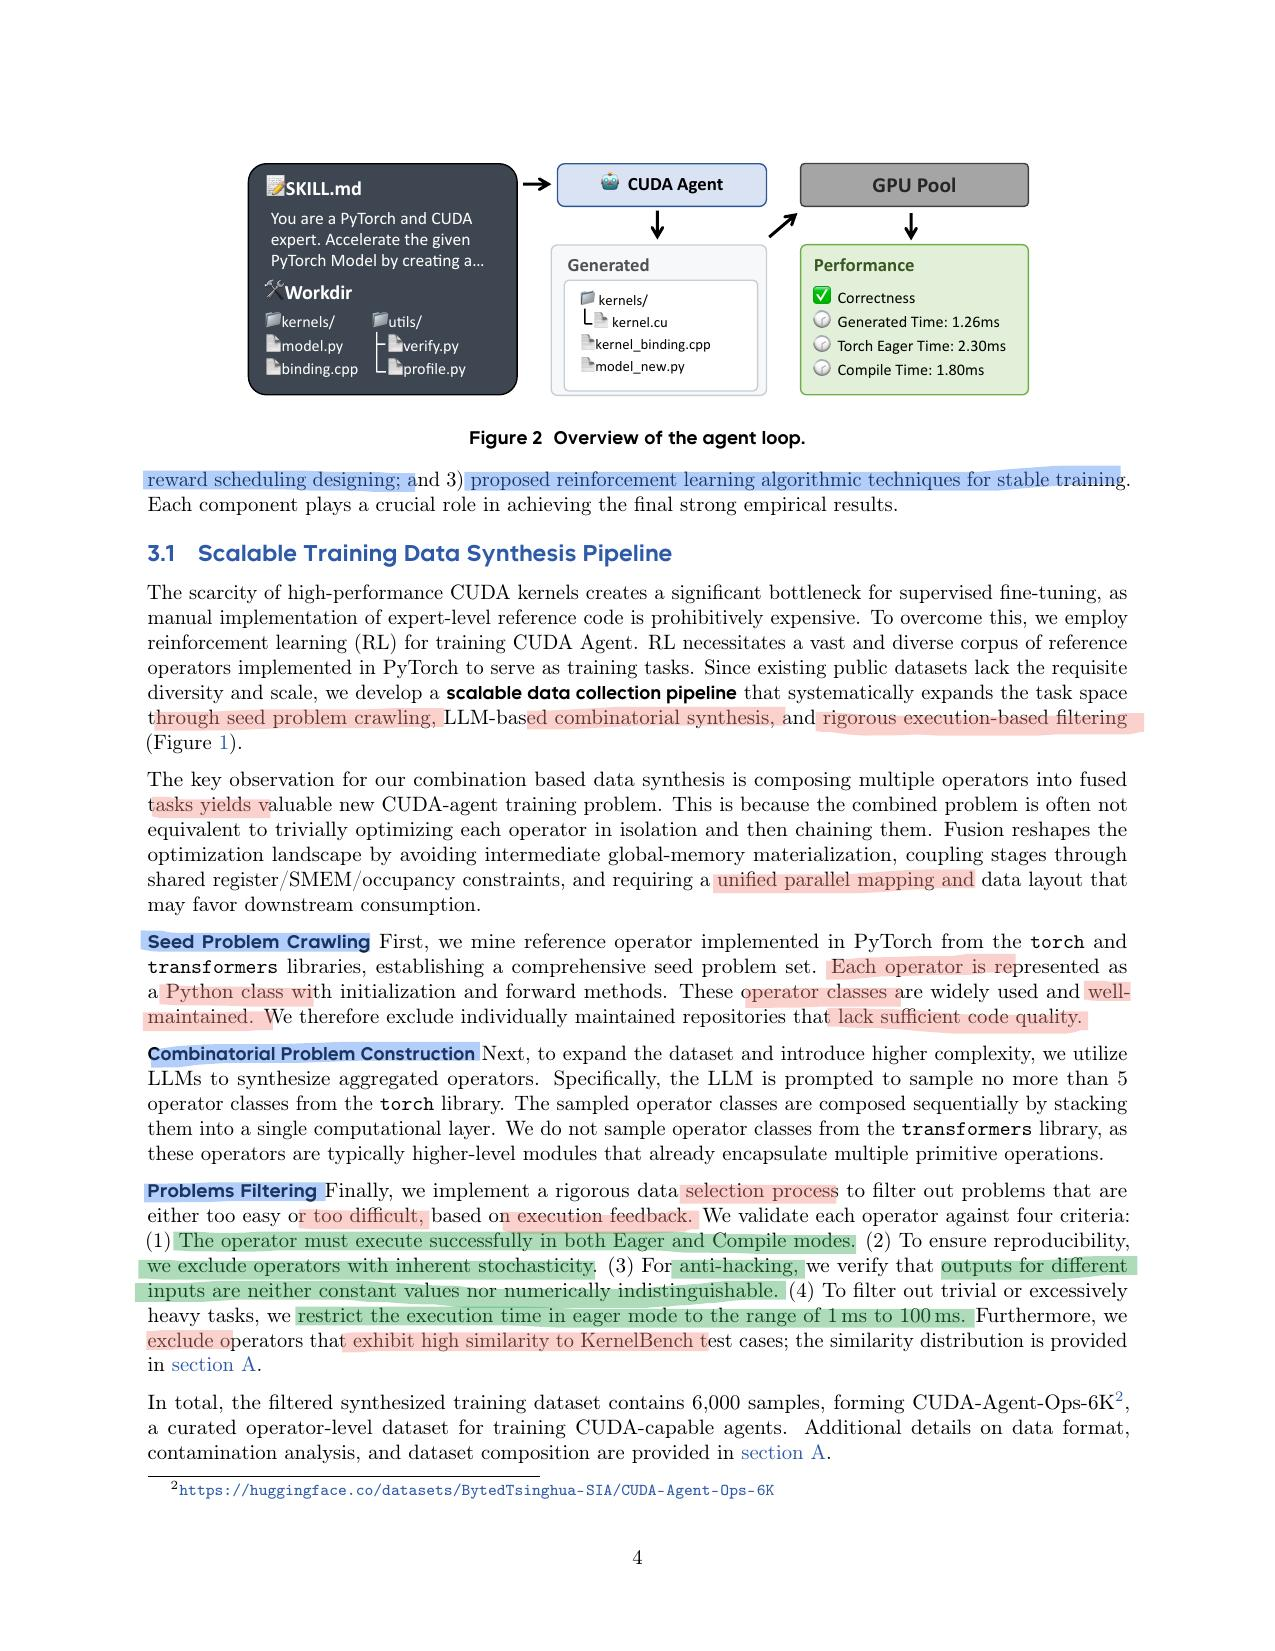

In [48]:


# query
query = "what is Single-Turn Warm-up?"
q_vec = client.models.embed_content(
    model=MODEL,
    contents=[types.Content(parts=[types.Part(text=query)])],
    config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY"),
).embeddings[0].values

hits = qdrant.query_points("pdf_pages", query=q_vec, limit=3).points

from IPython.display import display, Image as IPImage
for h in hits:
    print(f"page {h.payload['page']}  score={h.score:.4f}")
    display(IPImage(data=base64.b64decode(h.payload["image_b64"]), width=500))

### audio

In [49]:
!pip install qdrant-client google-genai ffmpeg-python -q
!apt-get install -q ffmpeg

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [53]:
!pip install qdrant-client google-genai ffmpeg-python gtts -q


In [ ]:
import os, base64
import ffmpeg
from gtts import gTTS
from google import genai
from google.genai import types
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance, PointStruct

qdrant  = QdrantClient(path="/content/db_audio")
MODEL   = "gemini-embedding-2-preview"

# generate a short ~90s speech with gTTS
text = """
The solar system contains eight planets. Mercury is the closest to the Sun and has no atmosphere.
Venus is the hottest planet due to its thick carbon dioxide atmosphere.
Earth is the only planet known to support life, with liquid water on its surface.
Mars is the red planet, with the largest volcano in the solar system called Olympus Mons.
Jupiter is the largest planet, a gas giant with the famous Great Red Spot storm.
Saturn has spectacular rings made of ice and rock.
Uranus rotates on its side with an extreme axial tilt.
Neptune is the farthest planet and has the strongest winds in the solar system.
"""

gTTS(text=text, lang="en", slow=False).save("solar.mp3")
total = float(ffmpeg.probe("solar.mp3")["format"]["duration"])
print(f"✓ Generated  {total:.0f}s of audio")

#split into 10s chunks
os.makedirs("chunks", exist_ok=True)
chunks, start, i = [], 0.0, 0
while start < total:
    end  = min(start + 10, total)
    if end - start < 2: break
    path = f"chunks/chunk_{i:02d}.mp3"
    (ffmpeg.input("solar.mp3", ss=start, t=end - start)
           .output(path, acodec="libmp3lame", audio_bitrate="64k", loglevel="error")
           .run(overwrite_output=True, quiet=True))
    chunks.append({"id": i, "start": start, "end": end, "path": path})
    start += 7; i += 1

print(f"✓ {len(chunks)} chunks")

In [ ]:
# embed & index
qdrant.recreate_collection("audio_chunks",
    vectors_config=VectorParams(size=3072, distance=Distance.COSINE))

for c in chunks:
    audio_bytes = open(c["path"], "rb").read()
    v = client.models.embed_content(
        model=MODEL,
        contents=[types.Content(parts=[
            types.Part(text=f"segment {c['start']:.0f}s–{c['end']:.0f}s"),
            types.Part.from_bytes(data=audio_bytes, mime_type="audio/mp3"),
        ])],
        config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT"),
    ).embeddings[0].values

    qdrant.upsert("audio_chunks", points=[PointStruct(
        id=c["id"], vector=v,
        payload={"start": c["start"], "end": c["end"],
                 "audio_b64": base64.b64encode(audio_bytes).decode()}
    )])
    print(f"  ✓ chunk {c['id']:02d}  {c['start']:.0f}s–{c['end']:.0f}s")


In [54]:

#query
from IPython.display import Audio, display

for query in ["largest planet gas giant", "rings made of ice and rock", "closest planet to the sun"]:
    q_vec = client.models.embed_content(
        model=MODEL,
        contents=[types.Content(parts=[types.Part(text=query)])],
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY"),
    ).embeddings[0].values

    hit = qdrant.query_points("audio_chunks", query=q_vec, limit=1).points[0]
    print(f"\nQ: '{query}'  →  {hit.payload['start']:.0f}s–{hit.payload['end']:.0f}s  [{hit.score:.4f}]")
    display(Audio(data=base64.b64decode(hit.payload["audio_b64"]), rate=44100))

✓ Generated  45s of audio
✓ 7 chunks


/tmp/ipykernel_163/1615290739.py:47: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qdrant.recreate_collection("audio_chunks",


  ✓ chunk 00  0s–10s
  ✓ chunk 01  7s–17s
  ✓ chunk 02  14s–24s
  ✓ chunk 03  21s–31s
  ✓ chunk 04  28s–38s
  ✓ chunk 05  35s–45s
  ✓ chunk 06  42s–45s

Q: 'largest planet gas giant'  →  21s–31s  [0.7242]



Q: 'rings made of ice and rock'  →  42s–45s  [0.5896]



Q: 'closest planet to the sun'  →  0s–10s  [0.7581]


## MRL

### Matryoshka Representation Learning (MRL)

Traditional embedding models produce a fixed-size vector, you get all dimensions or none.
**MRL trains the model to pack the most important semantic information into the first dimensions**,
so you can truncate the vector and it still works.

```
3072-dim ████████████████████████████████  full precision
 768-dim ████████████░░░░░░░░░░░░░░░░░░░░  4× smaller, <0.25% quality loss  ← sweet spot
 128-dim ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░  fast but weaker
```

Think of it like a Matryoshka doll, each smaller vector is a complete, functional version of the larger one nested inside.

> One rule: after truncating, you **must L2-normalize** the vector or cosine similarity breaks.

For a deeper dive into how MRL works under the hood → **[read the full post](https://mohamedarbi.xyz/posts/matryoshka)**

---

## Summary

| Experiment | Result |
|---|---|
| Image + caption retrieval | 10/12 queries retrieved correct figure |
| Image-only index (no captions) | **5/5** — model reads image content directly |
| Vector shift (caption vs caption+image) | cosine < 1.0 on all figures — image shifts the embedding |
| Audio chunk retrieval | semantic query → correct audio segment played |

The experiments confirm that `gemini-embedding-2-preview` genuinely encodes visual and audio content, it is not a text model that happens to accept images. Cross-modal retrieval works because all modalities share the same geometric space.

## References

- [Gemini Embedding 2 Google AI](https://ai.google.dev/gemini-api/docs/embeddings)
- [Qdrant documentation](https://qdrant.tech/documentation/)
- [CUDA Agent paper (source of figures used)](https://arxiv.org/pdf/2602.24286)
- [MRL blog post](https://mohamedarbi.xyz/posts/matryoshka)

---
If this notebook was useful, consider giving a ⭐ to [Qdrant on GitHub](https://github.com/qdrant/qdrant), the vector database powering this demo.


*Notebook by [Mohamed Arbi Nsibi](https://www.linkedin.com/in/mohammed-arbi-nsibi-584a43241/)*